# Cold Diffusion: CIFAR-10 Re-implementation

Re-implementation of *Cold Diffusion: Inverting Arbitrary Image Transforms Without Noise* (Bansal et al., 2022) on CIFAR-10. Walks through:

1. **Forward degradations** — visualizing inpainting, blur, and super-resolution as `D(x_0, t)` over `t = 0..T`.
2. **Reconstruction** — direct one-shot prediction vs. Algorithm 2 iterative sampling (inpainting).
3. **Sampler comparison** — Algorithm 1 (naive) vs Algorithm 2 (paper §3.3).
4. **Metrics** — FID / SSIM / RMSE over the test set, mirroring Tables 1–3.
5. **Comparison across degradations** — train blur and super-resolution alongside inpainting and compare.
6. **Algorithm 3 (our contribution)** — EMA-smoothed sampler that improves on Algorithm 2.

Run order: top to bottom. Cells assume a CUDA GPU. Checkpoints are written to Google Drive (on Colab) so they survive runtime resets — re-run a training cell in a fresh session and it will load the saved checkpoint instead of retraining.

## Setup

In [2]:
import sys, os, pathlib, subprocess

REPO_URL  = 'https://github.com/J0hns0n-Wang/CS4782_Final_Project.git'
REPO_NAME = 'CS4782_Final_Project'

def _find_root():
    here = pathlib.Path('.').resolve()
    for d in [here, *here.parents]:
        if (d / 'src' / '__init__.py').exists():
            return d
    for child in here.iterdir():
        if child.is_dir() and (child / 'src' / '__init__.py').exists():
            return child.resolve()
    return None

ROOT = _find_root()

# On Colab the kernel runs on a fresh remote VM with no project files.
# Clone from GitHub if we can't find src/.
if ROOT is None:
    if 'google.colab' in sys.modules or os.path.exists('/content'):
        target = pathlib.Path('/content') / REPO_NAME
        if not target.exists():
            subprocess.check_call(['git', 'clone', '--depth', '1', REPO_URL, str(target)])
        ROOT = target
    else:
        raise RuntimeError(f'Could not find src/__init__.py from {pathlib.Path(".").resolve()}')

os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print('project root:', ROOT)

# Install FID dependencies if not already present.
for pkg, mod in [('torchmetrics', 'torchmetrics'), ('torch-fidelity', 'torch_fidelity')]:
    try:
        __import__(mod)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

# Device selection: prefer TPU (torch_xla is preinstalled on Colab TPU
# runtimes), then CUDA, then CPU. NOTE: src/training/train.py uses vanilla
# PyTorch -- TPU runs will execute but won't be optimally fast without
# xm.mark_step / xm.optimizer_step / ParallelLoader rewrites. For best
# throughput on Colab free tier, choose the T4 GPU runtime.
try:
    import torch_xla.core.xla_model as xm  # type: ignore
    DEVICE = xm.xla_device()
    print('device: TPU (xla) ->', DEVICE)
except ImportError:
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    print('device:', DEVICE)

torch.manual_seed(0)

# Persistent checkpoint location. On Colab we mount Drive so checkpoints
# survive VM resets / runtime switches; locally we use the repo's results/
# folder. Every training cell writes to f'{CKPT_BASE}/<run_name>' and
# auto-loads from there in a fresh session.
CKPT_BASE = 'results/checkpoints'
if 'google.colab' in sys.modules:
    from google.colab import drive
    if not os.path.ismount('/content/drive'):
        drive.mount('/content/drive')
    CKPT_BASE = '/content/drive/MyDrive/cold_diffusion_ckpts'
os.makedirs(CKPT_BASE, exist_ok=True)
print('checkpoints ->', CKPT_BASE)

Mounted at /content/drive
checkpoints -> /content/drive/MyDrive/cold_diffusion_ckpts


In [3]:
from src.training.dataset import cifar10_loaders
from src.degradations import GaussianMaskInpainting, GaussianBlur, SuperResolution
from src.diffusion.cold import ColdDiffusion
from src.models.unet import UNet
from src.models.ema import EMA
from src.training.train import train

# Paper recipe (Appendix A.1, A.2): per-step batch 64, accumulate_every=2
# inside train() -> effective batch 128. Random horizontal flip is on by
# default in cifar10_loaders. lr 2e-5, EMA 0.995 every 10 grad steps,
# L1 loss -- all set as defaults in src/training/train.py.
train_loader, test_loader = cifar10_loaders(batch_size=64, num_workers=2)
x0_demo, _ = next(iter(test_loader))
x0_demo = x0_demo[:8].to(DEVICE)
print('demo batch:', x0_demo.shape, x0_demo.min().item(), x0_demo.max().item())


def load_ema_from(run_dir, model_factory, step=None, device=None):
    """Reload an EMA from a saved checkpoint dir.

    model_factory: zero-arg callable returning a fresh restoration network
                   (e.g. lambda: UNet(image_size=32)). Must match the
                   architecture that was trained.
    step: int step to load, or None for the latest checkpoint.
    """
    device = device or DEVICE
    run_dir = pathlib.Path(run_dir)
    ckpts = sorted(run_dir.glob('ckpt_*.pt'))
    if not ckpts:
        raise FileNotFoundError(f'no ckpt_*.pt in {run_dir}')
    path = (run_dir / f'ckpt_{step:06d}.pt') if step is not None else ckpts[-1]
    print(f'loading {path}')
    state = torch.load(path, map_location=device)
    base = model_factory()
    base.load_state_dict(state['model'])
    ema = EMA(base)
    ema.load_state_dict(state['ema'])
    ema.ema_model.to(device)
    return ema


def has_checkpoint(run_dir):
    p = pathlib.Path(run_dir)
    return p.exists() and any(p.glob('ckpt_*.pt'))

100%|██████████| 170M/170M [00:13<00:00, 12.3MB/s] 


demo batch: torch.Size([8, 3, 32, 32]) 0.0 1.0


## 1. Forward degradations

`D(x_0, t)` for `t = 0, T/4, T/2, 3T/4, T` for each operator.

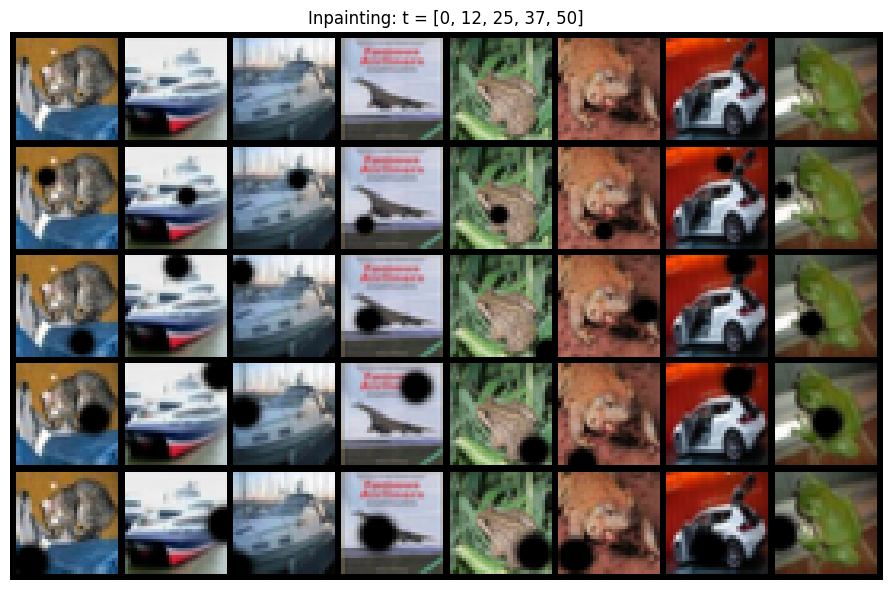

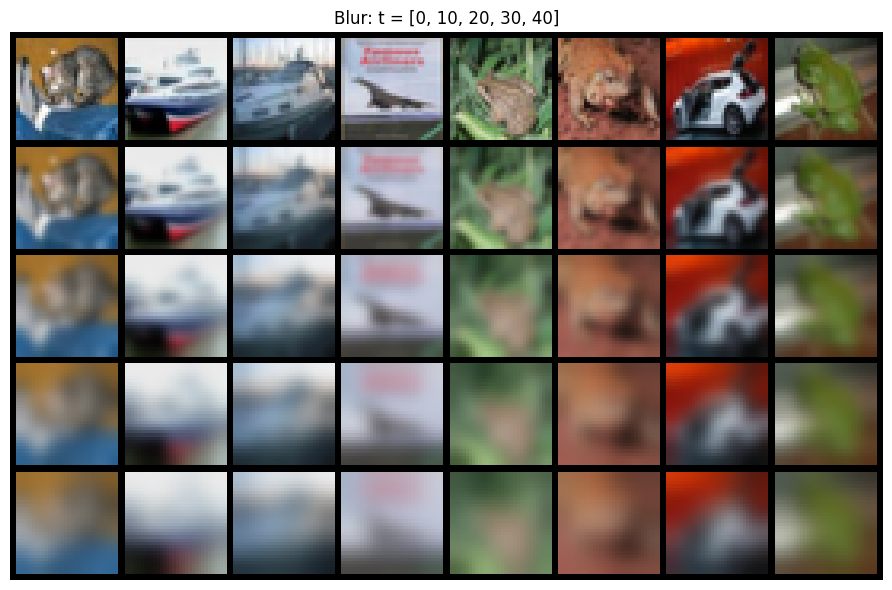

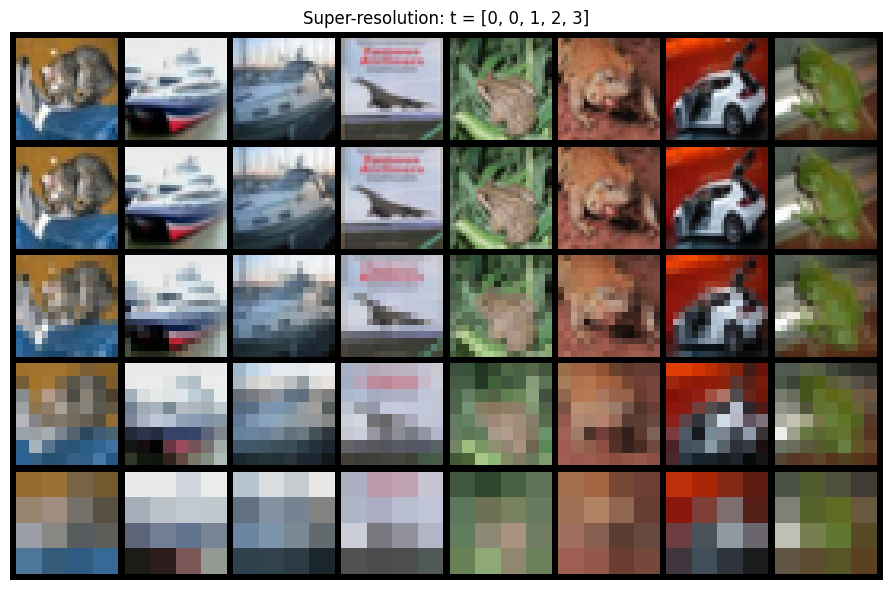

In [4]:
def show_degradation_progression(deg, T, x0, device, title=''):
    timesteps = [0, T // 4, T // 2, 3 * T // 4, T]
    rows = []
    deg = deg.to(device)
    for t_val in timesteps:
        t = torch.full((x0.shape[0],), t_val, device=device, dtype=torch.long)
        rows.append(deg(x0, t).clamp(0, 1).cpu())
    grid = make_grid(torch.cat(rows), nrow=x0.shape[0])
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(grid.permute(1, 2, 0))
    ax.set_title(f'{title}: t = {timesteps}')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

show_degradation_progression(GaussianMaskInpainting(image_size=32, T=50, randomize_center=True), 50, x0_demo, DEVICE, 'Inpainting')
show_degradation_progression(GaussianBlur(kernel_size=11, T=40), 40, x0_demo, DEVICE, 'Blur')
show_degradation_progression(SuperResolution(image_size=32, T=3), 3, x0_demo, DEVICE, 'Super-resolution')

## 2. Train a Cold Diffusion model on the inpainting task

Paper recipe (Appendix A.2): 60k gradient steps at effective batch 128 (= per-step batch 64 × `accumulate_every=2`). On a Colab T4 this is roughly 3–4 hours. Set `TOTAL_STEPS` lower if you need to fit a single Colab session and just want to verify the pipeline.

Skip this cell if you've already saved a checkpoint.

In [ ]:
TOTAL_STEPS = 60_000   # paper recipe (Appendix A.2)
RUN_DIR = f'{CKPT_BASE}/inpainting_demo'

deg = GaussianMaskInpainting(image_size=32, T=50, randomize_center=True)

if has_checkpoint(RUN_DIR):
    print(f'Found existing inpainting checkpoint in {RUN_DIR}; loading instead of training.')
    ema = load_ema_from(RUN_DIR, lambda: UNet(image_size=32))
else:
    diffusion = ColdDiffusion(UNet(image_size=32), deg, T=50)
    ema = train(diffusion, train_loader, total_steps=TOTAL_STEPS,
                run_dir=RUN_DIR, device=DEVICE)

## 3. Reconstruction: direct vs Algorithm 2

In [ ]:
diff_eval = ColdDiffusion(ema.ema_model.to(DEVICE), deg.to(DEVICE), T=50).eval()
T = 50

with torch.no_grad():
    t_full = torch.full((x0_demo.shape[0],), T, device=DEVICE, dtype=torch.long)
    # Lock the per-image mask centers so xT and every D-call inside the
    # sampler share the same trajectory. Without this, Algorithm 2 sees
    # mismatched masks at every step and produces blob artifacts.
    state = diff_eval.sample_state(x0_demo)
    xT = diff_eval.q_sample(x0_demo, t_full, state=state)
    direct = diff_eval.predict_x0(xT, t_full).clamp(0, 1)
    sampled = diff_eval.sample_improved(xT, state=state).clamp(0, 1)

row_grid = torch.cat([xT.clamp(0,1).cpu(), direct.cpu(), sampled.cpu(), x0_demo.cpu()])
grid = make_grid(row_grid, nrow=x0_demo.shape[0])
fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(grid.permute(1, 2, 0))
ax.set_title('Rows: degraded | direct R(x_T,T) | Algorithm 2 sampled | original')
ax.axis('off')
plt.show()

## 4. Sampler comparison: Algorithm 1 vs Algorithm 2

Same trained model, same `xT`, same `state`. Only the reverse rule differs.

In [ ]:
with torch.no_grad():
    naive = diff_eval.sample_naive(xT, state=state).clamp(0, 1)
    improved = diff_eval.sample_improved(xT, state=state).clamp(0, 1)

comp = torch.cat([xT.clamp(0,1).cpu(), naive.cpu(), improved.cpu(), x0_demo.cpu()])
grid = make_grid(comp, nrow=x0_demo.shape[0])
fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(grid.permute(1, 2, 0))
ax.set_title('Rows: degraded | Algorithm 1 (naive) | Algorithm 2 (improved) | original')
ax.axis('off')
plt.show()

## 5. Quantitative metrics (Tables 1–3 style)

FID / SSIM / RMSE on the test set comparing degraded, direct, and sampled reconstructions to the originals.

In [ ]:
from src.evaluation.metrics import evaluate_diffusion

# Paper-faithful FID needs the full 10k test set; truncating to a few
# hundred samples inflates FID heavily.
results = evaluate_diffusion(diff_eval, test_loader, device=DEVICE)
for name, m in results.items():
    print(f'{name:>9s}  FID={m.fid:7.2f}  SSIM={m.ssim:.3f}  RMSE={m.rmse:.3f}')

## 6. Comparison across degradations

Train Cold Diffusion on **blur** and **super-resolution** in addition to inpainting (already trained above). All three share the same U-Net architecture and training loop — only `D` changes.

**Compute warning.** The paper uses 700k steps for blur and super-resolution (vs. 60k for inpainting). On a Colab T4 that's well past the free runtime limit. `COMPARE_STEPS` is set lower; the Algorithm 1 vs Algorithm 2 trend is visible by 30k. Super-resolution converges fastest (T=3) and is a good cheap addition.

In [ ]:
COMPARE_STEPS = 30_000   # adjust to your time budget; trends visible by 30k

# Blur: 11x11 Gaussian kernel, sigma_t = 0.01*t + 0.35, T=40 (paper Appendix A.1).
blur_deg = GaussianBlur(kernel_size=11, T=40)
blur_run_dir = f'{CKPT_BASE}/blur_demo'

if has_checkpoint(blur_run_dir):
    print(f'Found existing blur checkpoint in {blur_run_dir}; loading instead of training.')
    ema_blur = load_ema_from(blur_run_dir, lambda: UNet(image_size=32))
else:
    blur_diff = ColdDiffusion(UNet(image_size=32), blur_deg, T=40)
    ema_blur = train(blur_diff, train_loader, total_steps=COMPARE_STEPS,
                     run_dir=blur_run_dir, device=DEVICE)

In [ ]:
COMPARE_STEPS = 100_000   # adjust to your time budget; trends visible by 30k

# Super-resolution: 32 -> 16 -> 8 -> 4, T=3 (paper §4.3). Trains fastest of
# the three (only 3 timesteps).
sr_deg = SuperResolution(image_size=32, T=3)
sr_run_dir = f'{CKPT_BASE}/sr_demo'

if has_checkpoint(sr_run_dir):
    print(f'Found existing SR checkpoint in {sr_run_dir}; loading instead of training.')
    ema_sr = load_ema_from(sr_run_dir, lambda: UNet(image_size=32))
else:
    sr_diff = ColdDiffusion(UNet(image_size=32), sr_deg, T=3)
    ema_sr = train(sr_diff, train_loader, total_steps=COMPARE_STEPS,
                   run_dir=sr_run_dir, device=DEVICE)

train:   0%|          | 0/100000 [00:00<?, ?it/s]

step    100/100000  loss 0.1802  (8.6 it/s)
step    200/100000  loss 0.0874  (9.2 it/s)


### Side-by-side reconstruction grids

Same eight test images run through each model. Top to bottom in each grid: degraded input, direct reconstruction, Algorithm 2 sampled, original.

In [10]:
def reconstruct_grid(ema_obj, degradation, T, x0, device, title):
    diffusion = ColdDiffusion(ema_obj.ema_model.to(device), degradation.to(device), T=T).eval()
    with torch.no_grad():
        t_full = torch.full((x0.shape[0],), T, device=device, dtype=torch.long)
        state = diffusion.sample_state(x0)
        xT = diffusion.q_sample(x0, t_full, state=state)
        direct  = diffusion.predict_x0(xT, t_full).clamp(0, 1)
        sampled = diffusion.sample_improved(xT, state=state).clamp(0, 1)
    rows = torch.cat([xT.clamp(0,1).cpu(), direct.cpu(), sampled.cpu(), x0.cpu()])
    grid = make_grid(rows, nrow=x0.shape[0])
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.imshow(grid.permute(1, 2, 0))
    ax.set_title(f'{title} — Rows: degraded | direct | Algorithm 2 | original')
    ax.axis('off')
    plt.show()

# reconstruct_grid(ema,      deg,      50, x0_demo, DEVICE, 'Inpainting')
# reconstruct_grid(ema_blur, blur_deg, 40, x0_demo, DEVICE, 'Blur')
# reconstruct_grid(ema_sr,   sr_deg,    3, x0_demo, DEVICE, 'Super-resolution')

### Quantitative comparison (FID / SSIM / RMSE)

All three degradations evaluated on the full CIFAR-10 test set (10k images). Lower FID/RMSE and higher SSIM are better.

In [9]:
from src.evaluation.metrics import evaluate_diffusion


def print_metrics(name, ema_obj, degradation, T):
    diffusion = ColdDiffusion(ema_obj.ema_model.to(DEVICE), degradation.to(DEVICE), T=T).eval()
    res = evaluate_diffusion(diffusion, test_loader, device=DEVICE)
    print(f'== {name} ==')
    for k, m in res.items():
        print(f'  {k:>9s}  FID={m.fid:7.2f}  SSIM={m.ssim:.3f}  RMSE={m.rmse:.3f}')

# print_metrics('inpainting', ema, deg, 50)

In [ ]:
print_metrics('blur', ema_blur, blur_deg, 40)

In [ ]:
print_metrics('super_resolution', ema_sr, sr_deg, 3)

## 7. Algorithm 3 — EMA-smoothed sampler (our contribution)

Algorithm 2 calls `R(x_t, t)` once per sampler step and discards the prediction immediately. But across the `T` steps, R is repeatedly estimating the *same target* `x_0` from progressively-less-degraded inputs. Those predictions can be averaged.

**Algorithm 3** maintains an EMA of `x̂_0` across sampler steps and uses the smoothed estimate in the `D` updates:

$$\hat{x}_0^{(s)} \leftarrow \alpha \cdot \hat{x}_0^{(s+1)} + (1-\alpha)\cdot R(x_s, s), \qquad x_{s-1} = x_s - D(\hat{x}_0^{(s)}, s) + D(\hat{x}_0^{(s)}, s-1)$$

`alpha = 0` recovers Algorithm 2 exactly; `alpha = 1` freezes the very first prediction. The interesting regime is in between.

**Hypothesis (the asymmetry).** For *linear* `D` (blur), Algorithm 2 is already exact (paper §3.3) — Alg 3 should give negligible improvement. For *nonlinear* `D` (inpainting with stochastic per-image mask centers), Alg 3 should reduce per-step error and improve FID. The contrast is the point.

Implementation lives in [`src/diffusion/cold.py`](src/diffusion/cold.py) as `ColdDiffusion.sample_ema()`. Same trained model as Alg 1 / Alg 2 — no new training.

### 7.1 Visual comparison: Alg 1 vs Alg 2 vs Alg 3 (inpainting)

Same trained model, same `xT`, same `state` — only the reverse rule differs. With `alpha = 0.5` for the EMA.

In [ ]:
ALPHA = 0.5

inp_eval = ColdDiffusion(ema.ema_model.to(DEVICE), deg.to(DEVICE), T=50).eval()

with torch.no_grad():
    t_full = torch.full((x0_demo.shape[0],), 50, device=DEVICE, dtype=torch.long)
    state_inp = inp_eval.sample_state(x0_demo)
    xT_inp = inp_eval.q_sample(x0_demo, t_full, state=state_inp)
    alg1 = inp_eval.sample_naive   (xT_inp, state=state_inp).clamp(0, 1)
    alg2 = inp_eval.sample_improved(xT_inp, state=state_inp).clamp(0, 1)
    alg3 = inp_eval.sample_ema     (xT_inp, alpha=ALPHA, state=state_inp).clamp(0, 1)

rows = torch.cat([xT_inp.clamp(0,1).cpu(), alg1.cpu(), alg2.cpu(), alg3.cpu(), x0_demo.cpu()])
grid = make_grid(rows, nrow=x0_demo.shape[0])
fig, ax = plt.subplots(figsize=(12, 7))
ax.imshow(grid.permute(1, 2, 0))
ax.set_title(f'Inpainting — Rows: degraded | Alg 1 (naive) | Alg 2 (paper) | Alg 3 (EMA, α={ALPHA}) | original')
ax.axis('off')
plt.show()

### 7.2 α sweep (inpainting)

How sensitive is Alg 3 to the EMA decay? Sweep `alpha` and report FID/SSIM/RMSE on the test set. `alpha=0` is Algorithm 2 (control). Expect a U-shape: too little smoothing wastes the signal, too much (`alpha→1`) freezes a bad early prediction.

In [ ]:
import gc
from tqdm.auto import tqdm
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image import StructuralSimilarityIndexMeasure
from torchmetrics.regression import MeanSquaredError
from src.evaluation.metrics import _resize_for_inception

# Faster eval loader (bigger batches saturate the GPU on Inception forwards).
_, fast_test_loader = cifar10_loaders(batch_size=128, num_workers=8)

ALPHAS = [0.0, 0.3, 0.5, 0.7, 0.9]
inp_eval = ColdDiffusion(ema.ema_model.to(DEVICE), deg.to(DEVICE), T=50).eval()
T_inp = 50

results_alpha = {}
for a in ALPHAS:
    # Fresh metric modules per alpha so memory is bounded per iteration.
    fid  = FrechetInceptionDistance(normalize=False).to(DEVICE)
    ssim = StructuralSimilarityIndexMeasure(data_range=1.0).to(DEVICE)
    rmse = MeanSquaredError(squared=False).to(DEVICE)

    with torch.no_grad():
        for x0, _ in tqdm(fast_test_loader, desc=f'α={a:.1f}', leave=False):
            x0 = x0.to(DEVICE)
            t_full = torch.full((x0.shape[0],), T_inp, device=DEVICE, dtype=torch.long)
            state = inp_eval.sample_state(x0)
            xT = inp_eval.q_sample(x0, t_full, state=state)
            x_hat = inp_eval.sample_ema(xT, alpha=a, state=state).clamp(0, 1)

            fid.update(_resize_for_inception(x0),    real=True)
            fid.update(_resize_for_inception(x_hat), real=False)
            ssim.update(x_hat, x0)
            rmse.update(x_hat, x0)

            del x0, xT, x_hat
            torch.cuda.empty_cache()

    results_alpha[a] = (fid.compute().item(), ssim.compute().item(), rmse.compute().item())
    label = 'Alg 2 (α=0)' if a == 0.0 else f'Alg 3 α={a}'
    f, s, r = results_alpha[a]
    print(f'  {label:>13s}  FID={f:7.2f}  SSIM={s:.3f}  RMSE={r:.3f}')

    # Drop the metric modules + cached features before the next alpha.
    del fid, ssim, rmse
    gc.collect()
    torch.cuda.empty_cache()

# Plot FID vs alpha
fig, ax = plt.subplots(figsize=(6, 4))
xs = list(results_alpha.keys()); ys = [results_alpha[a][0] for a in xs]
ax.plot(xs, ys, marker='o')
ax.set_xlabel('alpha (EMA decay)'); ax.set_ylabel('FID (lower is better)')
ax.set_title('Inpainting — Algorithm 3 sensitivity to alpha')
ax.axhline(y=results_alpha[0.0][0], ls='--', alpha=0.5, label='Alg 2 baseline')
ax.legend(); ax.grid(alpha=0.3)
plt.show()

### 7.3 Linear vs nonlinear D — the asymmetry

The headline result. Algorithm 3 should show a clear FID improvement over Algorithm 2 on **inpainting** (nonlinear D — random per-image mask centers), and roughly tie on **blur** (linear D — Gaussian convolution is exactly linear, Algorithm 2 is already exact). Same `alpha` for both.

In [ ]:
ALPHA_BEST = 0.5   # pick the winner from the sweep above

tasks = [
    ('inpainting',       ema,      deg,      50),
    ('blur',             ema_blur, blur_deg, 40),
    ('super_resolution', ema_sr,   sr_deg,    3),
]

print(f'{"task":<20}{"sampler":<14}{"FID":>9}{"SSIM":>9}{"RMSE":>9}')
print('-' * 62)
rows_table = []
for name, ema_obj, degradation, T in tasks:
    diff = ColdDiffusion(ema_obj.ema_model.to(DEVICE), degradation.to(DEVICE), T=T).eval()
    samplers = {
        'Alg 2': lambda xT, state, d=diff: d.sample_improved(xT, state=state),
        'Alg 3': lambda xT, state, d=diff, a=ALPHA_BEST: d.sample_ema(xT, alpha=a, state=state),
    }
    for label, fn in samplers.items():
        # Fresh metric modules per (task, sampler); freed after compute.
        fid  = FrechetInceptionDistance(normalize=False).to(DEVICE)
        ssim = StructuralSimilarityIndexMeasure(data_range=1.0).to(DEVICE)
        rmse = MeanSquaredError(squared=False).to(DEVICE)

        with torch.no_grad():
            for x0, _ in tqdm(fast_test_loader, desc=f'{name} | {label}', leave=False):
                x0 = x0.to(DEVICE)
                t_full = torch.full((x0.shape[0],), T, device=DEVICE, dtype=torch.long)
                state = diff.sample_state(x0)
                xT = diff.q_sample(x0, t_full, state=state)
                x_hat = fn(xT, state).clamp(0, 1)

                fid.update(_resize_for_inception(x0),    real=True)
                fid.update(_resize_for_inception(x_hat), real=False)
                ssim.update(x_hat, x0)
                rmse.update(x_hat, x0)

                del x0, xT, x_hat
                torch.cuda.empty_cache()

        f, s, r = fid.compute().item(), ssim.compute().item(), rmse.compute().item()
        rows_table.append((name, label, f, s, r))
        print(f'{name:<20}{label:<14}{f:>9.2f}{s:>9.3f}{r:>9.3f}')

        del fid, ssim, rmse
        gc.collect()
        torch.cuda.empty_cache()

# Print the deltas (Alg 3 - Alg 2). Negative FID/RMSE = Alg 3 wins; positive SSIM = Alg 3 wins.
print()
print('Alg 3 - Alg 2 (negative FID/RMSE = Alg 3 wins; positive SSIM = Alg 3 wins):')
for i in range(0, len(rows_table), 2):
    name = rows_table[i][0]
    d_fid  = rows_table[i+1][2] - rows_table[i][2]
    d_ssim = rows_table[i+1][3] - rows_table[i][3]
    d_rmse = rows_table[i+1][4] - rows_table[i][4]
    print(f'  {name:<20}  ΔFID={d_fid:+.2f}  ΔSSIM={d_ssim:+.3f}  ΔRMSE={d_rmse:+.3f}')

## 8. MNIST experiments

Run the same Cold Diffusion pipeline on MNIST (28×28 grayscale, padded to 32×32 to fit the existing UNet config). MNIST is much easier than CIFAR-10 — fewer steps and a smaller model are usually enough.

**Compute note (TPU):** if you switched the runtime to TPU, the device above will read `TPU (xla)`. The training loop in [`src/training/train.py`](src/training/train.py) uses vanilla PyTorch (no `xm.mark_step` / `xm.optimizer_step` / `ParallelLoader`), so TPU runs will execute correctly but won't be much faster than CPU. For real speed, use a T4/L4 GPU runtime instead.

In [ ]:
from src.training.dataset import mnist_loaders

# 1-channel, 32x32 (28 padded with 2px on each side).
mnist_train_loader, mnist_test_loader = mnist_loaders(batch_size=64, num_workers=2)

x0_demo_mnist, _ = next(iter(mnist_test_loader))
x0_demo_mnist = x0_demo_mnist[:8].to(DEVICE)
print('mnist demo batch:', x0_demo_mnist.shape, x0_demo_mnist.min().item(), x0_demo_mnist.max().item())

# Quick viz: degraded progressions on a single MNIST example.
# Aggressive blur schedule so the digit is unrecognizable by t=T:
# sigma_t = 0.05*t + 0.5 (vs the mild 0.01*t + 0.35 default), kernel=17.
# Cumulative effective sigma ~9 pixels by t=40 -- digits become uniform blobs.
show_degradation_progression(GaussianMaskInpainting(image_size=32, T=50),                                     50, x0_demo_mnist, DEVICE, 'MNIST inpainting')
show_degradation_progression(GaussianBlur(kernel_size=17, T=40, sigma_fn=lambda t: 0.05*t + 0.5, channels=1), 40, x0_demo_mnist, DEVICE, 'MNIST blur')

### 8.1 Train on MNIST inpainting

UNet is built with `in_channels=1` to match grayscale MNIST. Same hyperparameters as the CIFAR-10 inpainting cell, just a smaller step budget — MNIST converges much faster.

In [7]:
MNIST_STEPS = 30_000   # MNIST converges much faster than CIFAR; 30k is plenty

mnist_inp_deg = GaussianMaskInpainting(image_size=32, T=50)
mnist_inp_run_dir = f'{CKPT_BASE}/mnist_inpainting'

if has_checkpoint(mnist_inp_run_dir):
    print(f'Found existing MNIST inpainting checkpoint in {mnist_inp_run_dir}; loading.')
    ema_mnist_inp = load_ema_from(mnist_inp_run_dir, lambda: UNet(image_size=32, in_channels=1))
else:
    mnist_inp_diff = ColdDiffusion(UNet(image_size=32, in_channels=1), mnist_inp_deg, T=50)
    ema_mnist_inp = train(mnist_inp_diff, mnist_train_loader, total_steps=MNIST_STEPS,
                          run_dir=mnist_inp_run_dir, device=DEVICE)

train:   0%|          | 0/30000 [00:00<?, ?it/s]

step    100/30000  loss 0.0949  (7.7 it/s)
step    200/30000  loss 0.0415  (8.0 it/s)
step    300/30000  loss 0.0316  (8.1 it/s)
step    400/30000  loss 0.0258  (8.1 it/s)
step    500/30000  loss 0.0224  (8.2 it/s)
step    600/30000  loss 0.0201  (8.2 it/s)
step    700/30000  loss 0.0185  (8.2 it/s)
step    800/30000  loss 0.0174  (8.2 it/s)
step    900/30000  loss 0.0162  (8.2 it/s)
step   1000/30000  loss 0.0153  (8.2 it/s)
step   1100/30000  loss 0.0148  (8.2 it/s)
step   1200/30000  loss 0.0142  (8.2 it/s)
step   1300/30000  loss 0.0136  (8.2 it/s)
step   1400/30000  loss 0.0130  (8.2 it/s)
step   1500/30000  loss 0.0127  (8.2 it/s)
step   1600/30000  loss 0.0123  (8.2 it/s)
step   1700/30000  loss 0.0120  (8.2 it/s)
step   1800/30000  loss 0.0116  (8.3 it/s)
step   1900/30000  loss 0.0114  (8.3 it/s)
step   2000/30000  loss 0.0110  (8.3 it/s)
step   2100/30000  loss 0.0109  (8.2 it/s)
step   2200/30000  loss 0.0106  (8.2 it/s)
step   2300/30000  loss 0.0104  (8.2 it/s)
step   2400

### 8.2 Train on MNIST blur

In [ ]:
# Severe blur: cumulative sigma_eff ~9 pixels by t=40 -- digits unrecognizable.
# Note: run_dir is "mnist_blur_severe" (new name) so any prior mild-blur
# checkpoint at "mnist_blur" isn't accidentally loaded -- the model has to
# match the schedule it was trained on.
mnist_blur_deg = GaussianBlur(kernel_size=17, T=40, sigma_fn=lambda t: 0.05*t + 0.5, channels=1)
mnist_blur_run_dir = f'{CKPT_BASE}/mnist_blur_severe'

if has_checkpoint(mnist_blur_run_dir):
    print(f'Found existing MNIST blur checkpoint in {mnist_blur_run_dir}; loading.')
    ema_mnist_blur = load_ema_from(mnist_blur_run_dir, lambda: UNet(image_size=32, in_channels=1))
else:
    mnist_blur_diff = ColdDiffusion(UNet(image_size=32, in_channels=1), mnist_blur_deg, T=40)
    ema_mnist_blur = train(mnist_blur_diff, mnist_train_loader, total_steps=MNIST_STEPS,
                           run_dir=mnist_blur_run_dir, device=DEVICE)

### 8.3 MNIST reconstruction grids

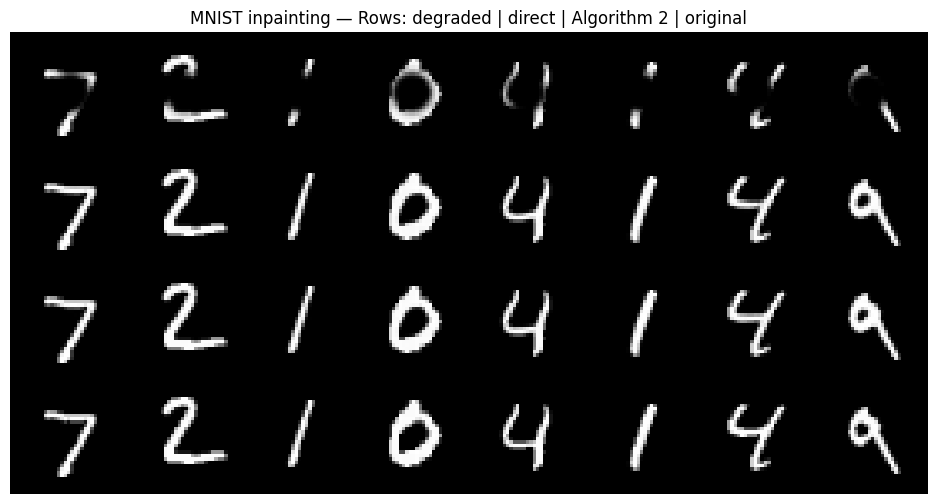

In [11]:
reconstruct_grid(ema_mnist_inp,  mnist_inp_deg,  50, x0_demo_mnist, DEVICE, 'MNIST inpainting')
# reconstruct_grid(ema_mnist_blur, mnist_blur_deg, 40, x0_demo_mnist, DEVICE, 'MNIST blur')

### 8.4 MNIST metrics

FID/SSIM/RMSE on the MNIST test set. **Note on FID:** Inception was trained on natural images; FID on grayscale MNIST is much noisier than on CIFAR. SSIM and RMSE are the more reliable metrics here. Expected paper-comparable values (Table 2): FID ~1-2, SSIM ~0.94, RMSE ~0.07.

In [13]:
# MNIST inpainting metrics. _resize_for_inception expands grayscale to RGB
# internally via the bilinear upsample (channels are preserved by interpolate),
# so we manually expand 1->3 channels on the fly inside the loop.

import gc
from tqdm.auto import tqdm
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image import StructuralSimilarityIndexMeasure
from torchmetrics.regression import MeanSquaredError
from src.evaluation.metrics import _resize_for_inception

mnist_tasks = [
    ('mnist_inpainting', ema_mnist_inp,  mnist_inp_deg,  50),
    # ('mnist_blur',       ema_mnist_blur, mnist_blur_deg, 40),
]

for name, ema_obj, degradation, T in mnist_tasks:
    diff = ColdDiffusion(ema_obj.ema_model.to(DEVICE), degradation.to(DEVICE), T=T).eval()
    fid  = FrechetInceptionDistance(normalize=False).to(DEVICE)
    ssim = StructuralSimilarityIndexMeasure(data_range=1.0).to(DEVICE)
    rmse = MeanSquaredError(squared=False).to(DEVICE)

    print(f'== {name} ==')
    metric_rows = {'degraded': (FrechetInceptionDistance(normalize=False).to(DEVICE),
                                 StructuralSimilarityIndexMeasure(data_range=1.0).to(DEVICE),
                                 MeanSquaredError(squared=False).to(DEVICE)),
                   'direct':   (FrechetInceptionDistance(normalize=False).to(DEVICE),
                                 StructuralSimilarityIndexMeasure(data_range=1.0).to(DEVICE),
                                 MeanSquaredError(squared=False).to(DEVICE)),
                   'sampled':  (FrechetInceptionDistance(normalize=False).to(DEVICE),
                                 StructuralSimilarityIndexMeasure(data_range=1.0).to(DEVICE),
                                 MeanSquaredError(squared=False).to(DEVICE))}

    with torch.no_grad():
        for x0, _ in tqdm(mnist_test_loader, desc=name, leave=False):
            x0 = x0.to(DEVICE)
            t_full = torch.full((x0.shape[0],), T, device=DEVICE, dtype=torch.long)
            state = diff.sample_state(x0)
            xT = diff.q_sample(x0, t_full, state=state)
            x_direct  = diff.predict_x0(xT, t_full).clamp(0, 1)
            x_sampled = diff.sample_improved(xT, state=state).clamp(0, 1)
            deg_img = xT.clamp(0, 1)

            # Inception expects 3 channels; replicate grayscale -> RGB.
            x0_rgb       = _resize_for_inception(x0.expand(-1, 3, -1, -1))
            deg_rgb      = _resize_for_inception(deg_img.expand(-1, 3, -1, -1))
            direct_rgb   = _resize_for_inception(x_direct.expand(-1, 3, -1, -1))
            sampled_rgb  = _resize_for_inception(x_sampled.expand(-1, 3, -1, -1))

            for key, fake_rgb, fake in (('degraded', deg_rgb,     deg_img),
                                          ('direct',   direct_rgb,  x_direct),
                                          ('sampled',  sampled_rgb, x_sampled)):
                f, s, r = metric_rows[key]
                f.update(x0_rgb, real=True)
                f.update(fake_rgb, real=False)
                s.update(fake, x0)
                r.update(fake, x0)

            del x0, xT, x_direct, x_sampled, deg_img, x0_rgb, deg_rgb, direct_rgb, sampled_rgb
            torch.cuda.empty_cache()

    for key in ('degraded', 'direct', 'sampled'):
        f, s, r = metric_rows[key]
        print(f'  {key:>9s}  FID={f.compute().item():7.2f}  SSIM={s.compute().item():.3f}  RMSE={r.compute().item():.3f}')

    del metric_rows
    gc.collect()
    torch.cuda.empty_cache()

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 382MB/s]


== mnist_inpainting ==


mnist_inpainting:   0%|          | 0/157 [00:00<?, ?it/s]

   degraded  FID=  91.32  SSIM=0.866  RMSE=0.181
     direct  FID=   4.06  SSIM=0.991  RMSE=0.044
    sampled  FID=   3.26  SSIM=0.990  RMSE=0.049
